In [2]:
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import json

In [2]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp')

data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [3]:
file_list

[PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4520.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4838.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3789.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4444.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_811.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3425.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_1808.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3859.json'),
 PosixPath('/common/users/dm1487/ktamp_da

In [4]:
for idx in range(30):
    with open(file_list[idx], 'r') as f:
        data = json.load(f)
        print(data['xml_path'])
        print("from file", data['reachability_radius'])
        goal_success = np.array(data['goal_success'])
        
        radius_step = 0.01
        max_radius = 1.6 + radius_step
        reachability_radius = 1.6

        for radius in np.arange(radius_step, max_radius, radius_step):
            goal_success_radius = goal_success[goal_success[:, 0]**2 + goal_success[:, 1]**2 <= radius**2]
            if len(goal_success_radius) == 0:
                continue
            if np.sum(goal_success_radius[:, 2]) / len(goal_success_radius) < 1.0:
                
                break
            reachability_radius = radius

    print("reachability radius", reachability_radius)

        # plt.scatter(goal_success_radius[:, 0], goal_success_radius[:, 1], c=goal_success_radius[:, 2], cmap='RdBu')

        # break
    
    # plt.xlim(-1.6, 1.6)
    # plt.ylim(-1.6, 1.6)
    # plt.show()


    # plt.scatter(goal_success[:, 0], goal_success[:, 1], c=goal_success[:, 2], cmap='RdBu')
    # # goal_success = np.array(data['goal_success'])[:, -1].reshape(17, 17, 1)
    # # plt.imshow(goal_success, cmap='gray')
    # plt.show()
    # plt.colorbar()

cylinder_envs/1_movable/env_config_4520.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_4838.xml
from file 1.800000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3789.xml
from file 1.5500000000000007
reachability radius 1.59
cylinder_envs/1_movable/env_config_4444.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_811.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3425.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_1808.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3859.xml
from file 1.4500000000000006
reachability radius 1.46
cylinder_envs/1_movable/env_config_1474.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3541.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_97

In [51]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_new_temp_1')
data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [52]:
with open(file_list[0], 'r') as f:
    data = json.load(f)

(40, 40)
(40, 40)
(40, 40)
(40, 40)


Text(0.5, 1.0, 'Robot Mask')

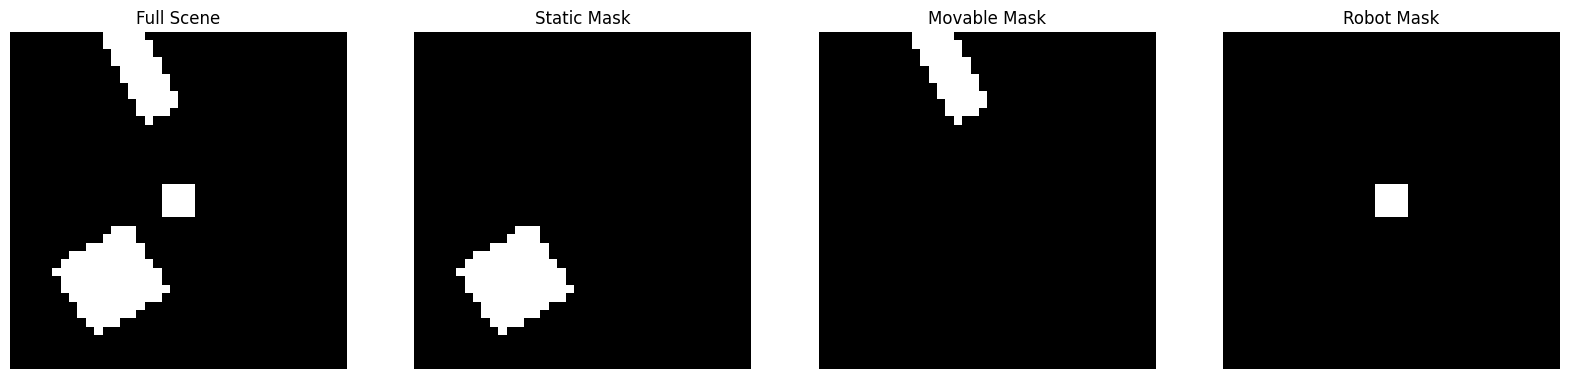

In [55]:
full_scene = np.array(data['scene_images']['full_scene'])
static_mask = np.array(data['scene_images']['static_mask'])
movable_mask = np.array(data['scene_images']['movable_mask'])
robot_mask = np.array(data['scene_images']['robot_mask'])

print(full_scene.shape)
print(static_mask.shape)
print(movable_mask.shape)
print(robot_mask.shape)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(full_scene, cmap='gray')
axs[0].axis('off')
axs[0].set_title('Full Scene')

axs[1].imshow(static_mask, cmap='gray')
axs[1].axis('off')
axs[1].set_title('Static Mask')

axs[2].imshow(movable_mask, cmap='gray')
axs[2].axis('off')
axs[2].set_title('Movable Mask')

axs[3].imshow(robot_mask, cmap='gray')
axs[3].axis('off')
axs[3].set_title('Robot Mask')

In [49]:
folder = Path("namo_trajectories")
file_list = list(folder.glob('*.txt'))
lines = []
for i in file_list:
    with open(i, 'r') as f:
        data = f.readlines()
    for line in data:
        line = np.array(line.strip().split()).astype(float)
        lines.append(line)
lines = np.array(lines)

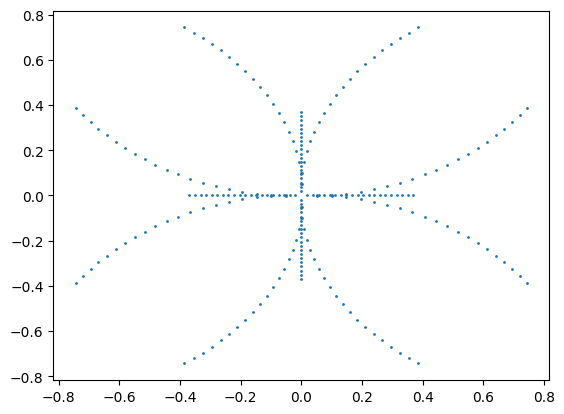

In [52]:
plt.scatter(lines[:, 0], lines[:, 1], s=1)

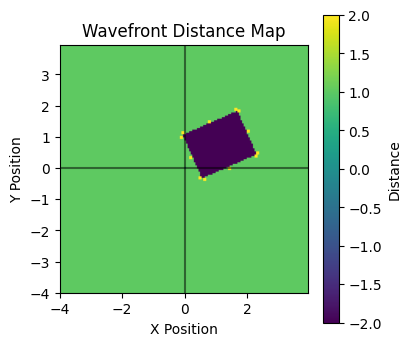

In [3]:
from matplotlib.patches import Rectangle
data = []
with open("wavefront_data.txt", "r") as f:
    for line in f:
        data.append([float(x) for x in line.strip().split()])
        
data = np.array(data)
grid_size = len(np.unique(data[:, 0]))

grid = data[:, -1].reshape(grid_size, grid_size)


x_lims = [np.min(np.unique(data[:, 0])), np.max(np.unique(data[:, 0]))]
y_lims = [np.min(np.unique(data[:, 1])), np.max(np.unique(data[:, 1]))]

# Create a figure with a larger size
plt.figure(figsize=(4, 4))

# Plot with origin at center and correct orientation
plt.imshow(grid.T, origin='lower', extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]])

# Add grid lines
# plt.grid(True, linestyle='--', alpha=0.7)

# Add axes lines for x=0 and y=0
plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.5)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Wavefront Distance Map')

# Add colorbar with label
plt.colorbar(label='Distance')

In [48]:
grid_size

160

In [22]:
np.unique(data[:, 0])

array([-2.525, -2.475, -2.425, -2.375, -2.325, -2.275, -2.225, -2.175,
       -2.125, -2.075, -2.025, -1.975, -1.925, -1.875, -1.825, -1.775,
       -1.725, -1.675, -1.625, -1.575, -1.525, -1.475, -1.425, -1.375,
       -1.325, -1.275, -1.225, -1.175, -1.125, -1.075, -1.025, -0.975,
       -0.925, -0.875, -0.825, -0.775, -0.725, -0.675, -0.625, -0.575,
       -0.525, -0.475, -0.425, -0.375, -0.325, -0.275, -0.225, -0.175,
       -0.125, -0.075, -0.025,  0.025,  0.075,  0.125,  0.175,  0.225,
        0.275,  0.325,  0.375,  0.425,  0.475,  0.525,  0.575,  0.625,
        0.675,  0.725,  0.775,  0.825,  0.875,  0.925,  0.975,  1.025,
        1.075,  1.125,  1.175,  1.225,  1.275,  1.325,  1.375,  1.425,
        1.475,  1.525,  1.575,  1.625,  1.675,  1.725,  1.775,  1.825,
        1.875,  1.925,  1.975,  2.025,  2.075,  2.125,  2.175,  2.225,
        2.275,  2.325,  2.375,  2.425])

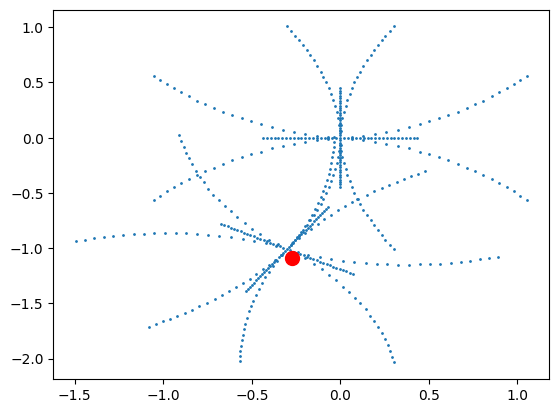

In [4]:
file = "search_states/search_states_final.txt"
lines = []
with open(file, 'r') as f:
        all_data = f.readlines()
        goal_line = all_data[0]
        goal_line = goal_line.split(" # goal:")[-1].strip().split()
        goal_line = np.array(goal_line).astype(float)
        data = all_data[1:]


for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines.append(line)
lines = np.array(lines)
plt.scatter(lines[:, 0], lines[:, 1], s=1)
plt.scatter(goal_line[0], goal_line[1], s=100, c='red')

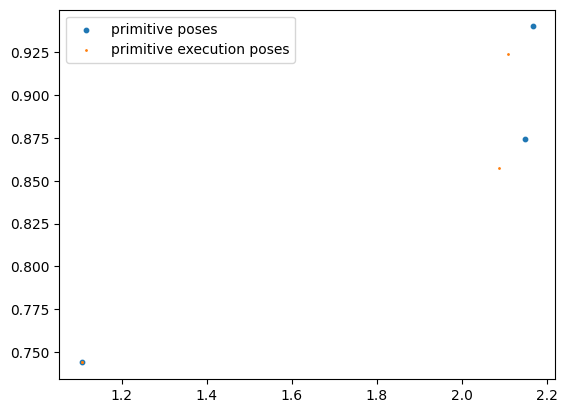

In [5]:
file_1 = "primitive_poses.txt"
file_2 = "primitive_execution_states.txt"
lines_1 = []
lines_2 = []
with open(file_1, 'r') as f:
        all_data = f.readlines()
        data = all_data

for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines_1.append(line)
lines_1 = np.array(lines_1)
plt.scatter(lines_1[:, 0], lines_1[:, 1], s=10, label="primitive poses")

with open(file_2, 'r') as f:
    all_data = f.readlines()
    data = all_data

for line in data:
    line = np.array(line.strip().split()).astype(float)
    lines_2.append(line)
lines_2 = np.array(lines_2)
plt.scatter(lines_2[:, 0], lines_2[:, 1], s=1, label="primitive execution poses")
plt.legend()